In [1]:
import torch

train_datasets = torch.load("/home/pkongsomjit/Projects/softprompt_experiments/train_mapper_dataset.pt", map_location="cpu", weights_only=True)

In [2]:
train_datasets[0]

{'task_name': 'task001_quoref_question_generation',
 'soft_prompt': tensor([[-3.7384e-03, -1.5564e-02, -6.1035e-03,  ...,  1.4038e-02,
          -4.2480e-02, -2.1118e-02],
         [-1.7700e-02,  1.2878e-02, -7.4768e-03,  ...,  1.2329e-02,
          -1.7700e-02,  2.3438e-02],
         [-1.3672e-02, -9.8228e-05, -6.6223e-03,  ..., -2.3682e-02,
           1.1139e-03,  2.6550e-03],
         ...,
         [ 1.9287e-02, -3.9551e-02, -2.0386e-02,  ...,  3.2043e-03,
           2.0996e-02, -6.1340e-03],
         [ 2.3651e-03, -9.3384e-03, -1.4465e-02,  ...,  1.5564e-02,
           9.9487e-03,  6.2256e-03],
         [-2.1851e-02, -9.3994e-03, -7.6294e-03,  ...,  2.9602e-03,
           2.7954e-02,  1.6968e-02]], dtype=torch.bfloat16, requires_grad=True),
 'soft_prompt_init_embeddings': tensor([[-0.0007, -0.0259, -0.0038,  ..., -0.0005, -0.0126, -0.0208],
         [-0.0088,  0.0045, -0.0017,  ...,  0.0139, -0.0117,  0.0225],
         [ 0.0016, -0.0075, -0.0013,  ...,  0.0026, -0.0007,  0.0021],
 

In [3]:
hardprompts_dict = {}
for d in train_datasets:
    hardprompt = d['hard_prompt']
    taskname = d['task_name']
    if hardprompts_dict.get(taskname, None):
        hardprompts_dict[taskname].append(hardprompt)
    else:
        hardprompts_dict[taskname] = [hardprompt]

  0%|          | 0/100 [00:00<?, ?it/s]

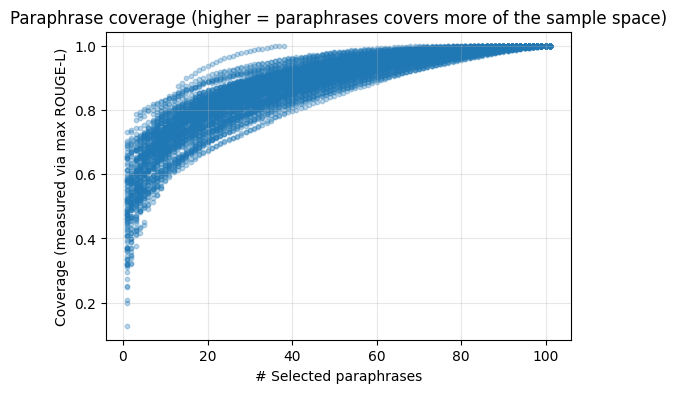

In [6]:
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.auto import tqdm

rouge = evaluate.load("rouge")

NUM_TASKS_TO_SAMPLE = 100
random.seed(42)

sampled_tasks = random.sample(
    list(hardprompts_dict.items()),
    k=min(NUM_TASKS_TO_SAMPLE, len(hardprompts_dict))
)

all_x = []
all_y = []

for task, prompts in tqdm(sampled_tasks):

    n = len(prompts)

    # -------------------------------------------------------
    # Compute all pairwise ROUGE-L scores in one batch
    # -------------------------------------------------------

    predictions = []
    references = []
    pairs = []

    for i in range(n):
        for j in range(i + 1, n):
            predictions.append(prompts[i])
            references.append(prompts[j])
            pairs.append((i, j))

    scores = rouge.compute(
        predictions=predictions,
        references=references,
        use_aggregator=False,
    )["rougeL"]

    S = np.eye(n)

    for (i, j), score in zip(pairs, scores):
        S[i, j] = score
        S[j, i] = score

    # -------------------------------------------------------
    # Greedy coverage
    # -------------------------------------------------------

    selected = [0]

    best_sim = S[0].copy()
    best_sim[0] = 1.0

    all_x.append(1)
    all_y.append(best_sim.mean())

    while len(selected) < n:

        remaining = np.setdiff1d(np.arange(n), selected)

        # Pick the least-covered remaining paraphrase
        next_idx = remaining[np.argmin(best_sim[remaining])]

        selected.append(next_idx)

        # Update coverage
        best_sim = np.maximum(best_sim, S[next_idx])

        all_x.append(len(selected))
        all_y.append(best_sim.mean())

plt.figure(figsize=(6, 4))
plt.scatter(all_x, all_y, s=10, alpha=0.3)
plt.xlabel("# Selected paraphrases")
plt.ylabel("Coverage (measured via max ROUGE-L)")
plt.title("Paraphrase coverage (higher = paraphrases covers more of the sample space)")
plt.grid(alpha=0.3)
plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

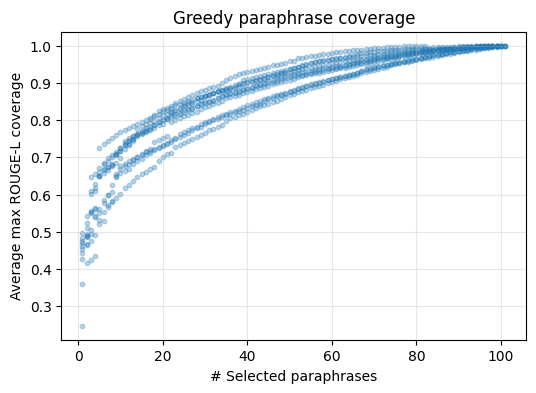

In [5]:
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.auto import tqdm

rouge = evaluate.load("rouge")

NUM_TASKS_TO_SAMPLE = 10
random.seed(42)

sampled_tasks = random.sample(
    list(hardprompts_dict.items()),
    k=min(NUM_TASKS_TO_SAMPLE, len(hardprompts_dict))
)

all_x = []
all_y = []

for task, prompts in tqdm(sampled_tasks):

    n = len(prompts)

    # -------------------------------------------------------
    # Compute all pairwise ROUGE-L scores in one batch
    # -------------------------------------------------------

    predictions = []
    references = []
    pairs = []

    for i in range(n):
        for j in range(i + 1, n):
            predictions.append(prompts[i])
            references.append(prompts[j])
            pairs.append((i, j))

    scores = rouge.compute(
        predictions=predictions,
        references=references,
        use_aggregator=False,
    )["rougeL"]

    S = np.eye(n)

    for (i, j), score in zip(pairs, scores):
        S[i, j] = score
        S[j, i] = score

    # -------------------------------------------------------
    # Greedy coverage
    # -------------------------------------------------------

    selected = [0]

    best_sim = S[0].copy()
    best_sim[0] = 1.0

    all_x.append(1)
    all_y.append(best_sim.mean())

    while len(selected) < n:

        remaining = np.setdiff1d(np.arange(n), selected)

        # Pick the least-covered remaining paraphrase
        next_idx = remaining[np.argmin(best_sim[remaining])]

        selected.append(next_idx)

        # Update coverage
        best_sim = np.maximum(best_sim, S[next_idx])

        all_x.append(len(selected))
        all_y.append(best_sim.mean())

plt.figure(figsize=(6, 4))
plt.scatter(all_x, all_y, s=10, alpha=0.3)
plt.xlabel("# Selected paraphrases")
plt.ylabel("Average max ROUGE-L coverage")
plt.title("Greedy paraphrase coverage")
plt.grid(alpha=0.3)
plt.show()